In [1]:
import os
os.makedirs("outputs", exist_ok=True)
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path
        
# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


PyTorch Tensors

Tensor Question 1

In [2]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

print(a.shape)
print(a.dtype)
print(a.device)

torch.Size([2, 3])
torch.float32
cpu


Q: what device are these tensors on right now? 
A: cpu

Q: If you were running a training loop on the GPU, why would it matter that your model weights and your input tensors are on the same device?
A: PyTorch will throw a runtime error as it is expenstive to move data between CPU and GPU.

Tensor Question 2

In [3]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
x_sqrt = torch.sqrt(x) 
print(x_sqrt)
x_sum = torch.sum(x)
print(x_sum)
x_mean = torch.mean(x)
print(x_mean)
x_argmax = torch.argmax(x)
print(x_argmax)

tensor([1., 2., 3., 4., 5.])
tensor(55.)
tensor(11.)
tensor(4)


Q: .argmax() appears in nearly every inference example you'll encounter. In the context of a classifier that outputs scores for 1,000 classes, what does .argmax() give you?
A: .argmax() gives the index of the most likely winner on the actual list.

Tensor Question 3

In [4]:
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


Q: why does PyTorch require .cpu() before you can call .numpy()? What does this tell you about where NumPy arrays live?

A: NumPy operates only in RAM managed by CPU.  Because tensors can exist in GPU, we must move it to CPU first if we want to use NumPy operations.  This tell us about NumPy arrays residing in CPU only.

Tensor Question 4

In [5]:
t = torch.arange(24).float()
t1 = torch.reshape(t, (4, 6))
print(t1.shape)
t2 = torch.reshape(t, (2, 3, 4))
print(t2.shape)
t3 = t1.unsqueeze(0)
print(t3.shape)

torch.Size([4, 6])
torch.Size([2, 3, 4])
torch.Size([1, 4, 6])


Q: a single image tensor typically has shape (channels, height, width). Neural networks expect batches with shape (batch_size, channels, height, width). What operation accomplishes this when you are processing one image at a time, and why does it matter?

A: The unsqueeze operation can accomplish this.  It matters because most models expects the batch dimenstion at the position 0 of the data.  By adding the batch dimenstion, the data is now compatible to be processed by most models.

Tensor Question 5

In [6]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

np_mp = np.matmul(np_a, np_b)
print(np_mp)
t_mp = torch.matmul(t_a, t_b)
print(t_mp)

[[19. 22.]
 [43. 50.]]
tensor([[19., 22.],
        [43., 50.]])


Q: At a high level, what role does matrix multiplication play as data passes through a single layer of a neural network?
A: It acts as a weighted filter by transforming raw data into meaningful patterns that the next layer of the network can understand.

Pretrained Models

Model Question 1

In [7]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]

Total parameters:     11,689,512
Trainable parameters: 11,689,512


Q: ResNet18 has roughly 11 million parameters. Training it from scratch required approximately 1.2 million labeled ImageNet images and days of multi-GPU compute. What does that tell you about the practical value of starting from pretrained weights when you're on a deadline or a budget?

A: It's an effective way to achieve the results without needing to spend a lot of resources or time.

Model Question 2

In [8]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Q: What is the name of the final layer in ResNet18, and what is its output size? (This number is the total count of ImageNet categories the model can predict.)

A: The name of the final layer is fc and its outputsize is 1000.

Q: Can you identify the blocks named layer1 through layer4? These are the "deep" part of the network — the feature extractor. In plain terms, what does it mean for a network to be "deep"?

A: Yes.  To be deep means that it uses many layers to take the simple output from one stage and build it into more complex patterns in the next.

Model Question 3 

In [9]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

Model ready for inference.


Q:What does .to(device) do, and why does it need to match the device your input tensors will be on?
A: It moves the model to GPU if available and if not it will be in CPU.  Both the tensors and model need to be on the same device for the data to be processed.

Q: What does model.eval() change about the model's behavior? Name at least one layer type that behaves differently in training mode vs. evaluation mode.
A: It changes from training mode to evaluation mode where no learning happens and the model is not allowed to adjust itself using test data.  It disables dropout and batch normalization training behavior.    


Model Question 4

In [10]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Q: What does the resize/crop step accomplish?
A: It converts every input image into the fixed size to match the exact shape that the model expects.

Q: What does ToTensor() do to the pixel value range?
A: It converts the raw range to the scaled range, 0 - 1.0.

Q: What is normalization doing, and why does it use ImageNet's specific mean and standard deviation values rather than, say, mean=0.5, std=0.5?
A:  Normalization adjusts the colors and brightness so that they are around a specific average.  It uses ImageNet's specific mean and standard deviation values because those were what the model was trained on.  Otherwise, the model might not recognize the data normalized at a different mean and std.  

Running Inference

In [11]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


Inference Question 1

In [12]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    image_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))
    with torch.inference_mode():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)
    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])

    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    top_probs, top_indices = probs.topk(5, dim=1)
    top_probs = top_probs.squeeze().tolist()
    top_indices = top_indices.squeeze().tolist()

    # Step 5: Build and return a list of (class_name, probability) tuples
    predicts = []
    for i in range(5):
        class_name = class_labels[top_indices[i]]
        probability = top_probs[i]
        predicts.append((class_name, probability))
    return predicts

img, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


Q: Does the top prediction make sense? Remember that the model was trained on ImageNet's 1,000 categories, which include things like "alp", "valley", and "lakeside" rather than simply "mountain". Do any of the top-5 labels map onto what you'd describe as a mountain scene?

A: The prediction makes sense.  Even though "mountain" is not in the trained model, its top picks incude specific types of mountain landscape.

Inference Question 2

In [13]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


Q: which classes does the model seem most confident about (high top-1 probability)? Which does it seem least confident about? Is there a pattern?

A: The model seem most confident about the mountain and least confident about the street.  The pattern is that it is only confident if the image has a specific object that it knows and has low confident when there is no clearly defined objects and it is just a generic scene.

In [14]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


Q: why do neural networks output logits internally rather than probabilities? In a production pipeline that needs to filter out low-confidence predictions, which representation would you work with — logits or probabilities — and why?

A: They output logits because it's more stable number when calculating the gradient if the proabilities are used, the values can get so small and unstable.  In the production pipeline that needs to filter out low-confidence predictions, I would work with probabilities as they provide the standardized confidence scale 0 - 100%.  Logits don't clearly show how confident the model is until they are converted to the probabilities. 

Inference Question 4

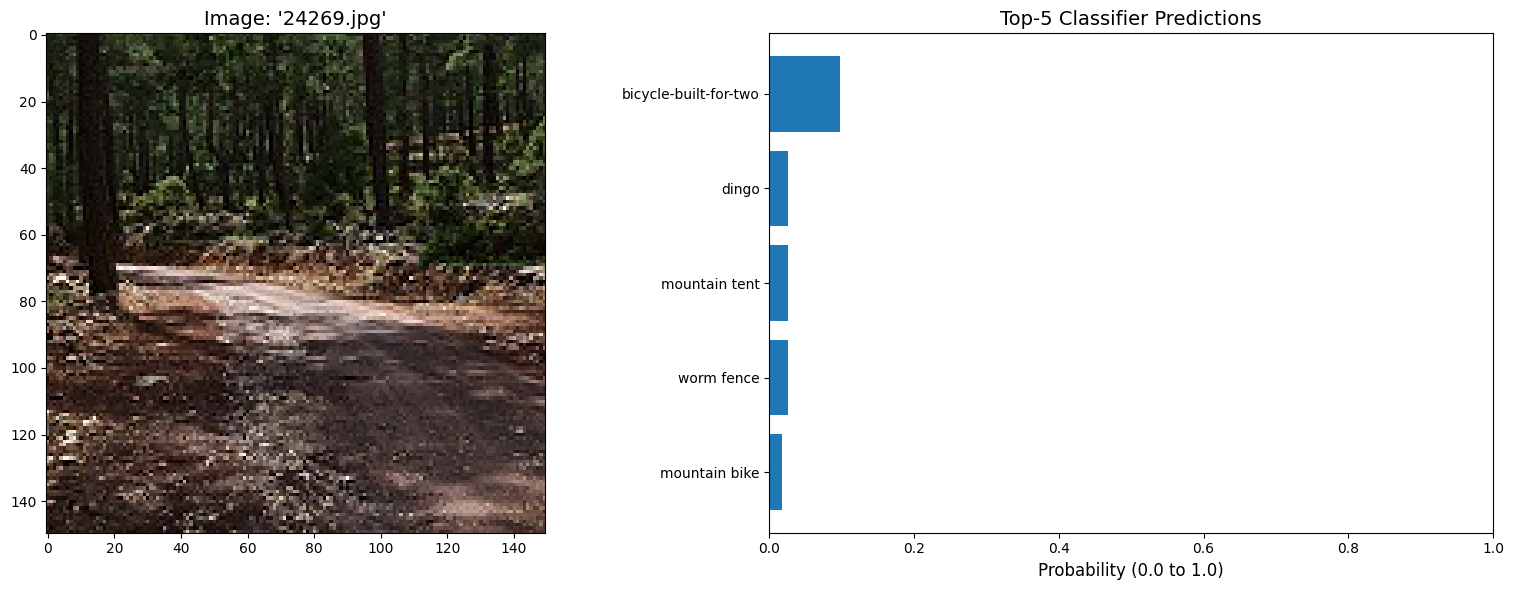

In [29]:
preds_forest = get_top5_predictions(model, preprocess, img, device, imagenet_classes)
arr = np.array(preds_forest)
top_labels, top_prob = list(arr[:, 0]), [float(x) for x in arr[:, 1]][::-1]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.imshow(img)
ax1.set_title(f"Image: '{img_name}'", fontsize=14)

ax2.barh(top_labels, top_prob)
ax2.set_title('Top-5 Classifier Predictions', fontsize=14)
ax2.set_xlabel('Probability (0.0 to 1.0)', fontsize=12)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('./outputs/warmup_inference_viz.png')

Q: how would you adapt this kind of visualization for a dashboard that a non-technical team member needs to review flagged predictions? What threshold on the top-1 probability might you use to decide when a prediction is "confident enough" to act on?

I would adapt by displaying the probabilities in the % format to make them easier to read.  I would also add a color-coded filter based on the probability: Green for >80%, Yellow for 50-80%, and Red for (<50%).